# 06 — Anomaly Detection

**Business question:** which building-days look operationally unusual
enough to deserve investigation — not "which are broken." Uses Isolation
Forest, evaluated against 147 genuinely injected anomalies held out from
every other stage.

**This notebook keeps the false starts.** The first two approaches tried
here scored badly, and figuring out *why* is more informative than
hiding it and only showing the version that worked — and it's exactly
the kind of thing worth being able to explain in an interview.

**Note on scope, unlike Models 1 and 2:** this is retrospective
("which past days were unusual"), not a forecast, so there's no
train/2024-test split — the model is fit on the full cleaned history.

**Note on features, unlike Models 1 and 2:** Models 1/2 excluded the
target's own same-day value from inputs (leakage, for *prediction*).
Anomaly detection is different — the question is "does this value fit
its context?", so the value itself belongs in the feature set.

> ⚠️ Source data is synthetic/simulated — see `data/README.md`.


In [1]:
import sys
sys.path.insert(0, "../src")
from feature_engineering import load_processed_tables, build_daily_analysis_table, add_calendar_features
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.metrics import precision_score, recall_score, f1_score

tables = load_processed_tables()
daily = build_daily_analysis_table(tables)
daily = add_calendar_features(daily)

gt = pd.read_csv("../data/processed/_validation_only_injected_anomalies.csv", parse_dates=["date"])
gt_set = set(zip(gt.building_id, gt.date))
daily["is_true_anomaly"] = list(zip(daily.building_id, daily.date))
daily["is_true_anomaly"] = daily["is_true_anomaly"].isin(gt_set)
print(f"{daily.shape[0]:,} rows | true anomaly rate: {daily.is_true_anomaly.mean():.4%} ({daily.is_true_anomaly.sum()})")


91,350 rows | true anomaly rate: 0.1609% (147)


## Attempt 1 - rich multivariate features, whole-year z-score

**What:** per-building z-score of `electricity_kwh` (computed across each
building's full 5-year history) plus temperature, occupancy, operating
hours, weekday, cyclical month, and building type - seven feature groups,
13 dimensions after one-hot encoding. The reasoning going in: more
context should let the model separate "unusual" from "expected given the
weather/occupancy that day."


In [2]:
daily["elec_zscore_annual"] = daily.groupby("building_id")["electricity_kwh"].transform(lambda s: (s - s.mean()) / s.std())

FEATURE_COLS_RICH = ["elec_zscore_annual", "temperature_f", "occupancy_rate", "operating_hours", "weekday", "month_sin", "month_cos"]
X_rich = pd.get_dummies(daily[FEATURE_COLS_RICH + ["building_type"]], columns=["building_type"])

iso1 = IsolationForest(n_estimators=200, contamination=0.005, random_state=42, n_jobs=-1)
flagged1 = iso1.fit_predict(X_rich) == -1
p, r, f1 = (precision_score(daily.is_true_anomaly, flagged1, zero_division=0),
            recall_score(daily.is_true_anomaly, flagged1, zero_division=0),
            f1_score(daily.is_true_anomaly, flagged1, zero_division=0))
print(f"Attempt 1 (13-dim, annual z-score): precision={p:.1%}  recall={r:.1%}  f1={f1:.3f}")
print("Weak. Before tuning contamination, checking WHY -- not just accepting a bad number.")


Attempt 1 (13-dim, annual z-score): precision=3.3%  recall=10.2%  f1=0.050
Weak. Before tuning contamination, checking WHY -- not just accepting a bad number.


### Diagnosis 1: the annual z-score confounds seasonality with anomaly

Checking one of the most-flagged buildings directly.


In [3]:
b45 = daily[daily.building_id == "B045"]
print("B045: mean elec_zscore_annual by month (should be flat if this were a fair baseline):")
print(b45.groupby("month")["elec_zscore_annual"].mean().round(2))
print(f"\ncorrelation(elec_zscore_annual, temperature_f), whole portfolio: {daily.elec_zscore_annual.corr(daily.temperature_f):.3f}")
print("\nConfirmed: the annual z-score runs ~1.2-1.4 every single summer for this building, purely from normal")
print("seasonality -- not anomalies. The model is partly rediscovering 'summer is hot' as 'unusual.'")


B045: mean elec_zscore_annual by month (should be flat if this were a fair baseline):
month
1    -0.83
2    -0.87
3    -0.97
4    -0.41
5     0.50
6     1.24
7     1.39
8     1.20
9     0.66
10   -0.18
11   -0.88
12   -0.91
Name: elec_zscore_annual, dtype: float64

correlation(elec_zscore_annual, temperature_f), whole portfolio: 0.150

Confirmed: the annual z-score runs ~1.2-1.4 every single summer for this building, purely from normal
seasonality -- not anomalies. The model is partly rediscovering 'summer is hot' as 'unusual.'


## Attempt 2 - fix the seasonality confound

**Fix:** z-score computed **per building AND per month**, so a day is
compared against that building's own typical range for *that season*,
not the whole year.


In [4]:
daily["elec_zscore"] = daily.groupby(["building_id", "month"])["electricity_kwh"].transform(lambda s: (s - s.mean()) / s.std())

print("B045: mean elec_zscore by month AFTER the fix:")
print(daily[daily.building_id == "B045"].groupby("month")["elec_zscore"].mean().round(3))
print(f"correlation(elec_zscore, temperature_f) after fix: {daily.elec_zscore.corr(daily.temperature_f):.3f}  (was 0.15+ before)")

X_rich2 = pd.get_dummies(daily[["elec_zscore","temperature_f","occupancy_rate","operating_hours","weekday","month_sin","month_cos","building_type"]], columns=["building_type"])
iso2 = IsolationForest(n_estimators=200, contamination=0.005, random_state=42, n_jobs=-1)
flagged2 = iso2.fit_predict(X_rich2) == -1
p, r, f1 = (precision_score(daily.is_true_anomaly, flagged2, zero_division=0),
            recall_score(daily.is_true_anomaly, flagged2, zero_division=0),
            f1_score(daily.is_true_anomaly, flagged2, zero_division=0))
print(f"\nAttempt 2 (13-dim, monthly z-score): precision={p:.1%}  recall={r:.1%}  f1={f1:.3f}")
print("The seasonality confound is genuinely fixed (correlation ~0), but detection quality barely moved.")
print("The seasonality bug wasn't the main problem -- something else is limiting this feature set.")


B045: mean elec_zscore by month AFTER the fix:
month
1     0.0
2     0.0
3     0.0
4    -0.0
5     0.0
6     0.0
7     0.0
8     0.0
9     0.0
10    0.0
11    0.0
12    0.0
Name: elec_zscore, dtype: float64
correlation(elec_zscore, temperature_f) after fix: 0.030  (was 0.15+ before)

Attempt 2 (13-dim, monthly z-score): precision=2.6%  recall=8.2%  f1=0.040
The seasonality confound is genuinely fixed (correlation ~0), but detection quality barely moved.
The seasonality bug wasn't the main problem -- something else is limiting this feature set.


## Attempt 3 - test whether the extra context features are actually helping

Hypothesis: with 13 dimensions and Isolation Forest randomly selecting a
feature to split on at each node, the one genuinely informative feature
(`elec_zscore`) gets diluted among twelve mostly-redundant ones (weekday
and month are largely redundant with a z-score that's already
month-normalized; building type is largely redundant with z-score being
computed per-building in the first place).


In [5]:
def evaluate(X, label, contamination=0.005):
    iso = IsolationForest(n_estimators=200, contamination=contamination, random_state=42, n_jobs=-1)
    flagged = iso.fit_predict(X) == -1
    p = precision_score(daily.is_true_anomaly, flagged, zero_division=0)
    r = recall_score(daily.is_true_anomaly, flagged, zero_division=0)
    f1 = f1_score(daily.is_true_anomaly, flagged, zero_division=0)
    print(f"{label:40s} (dims={X.shape[1]:2d})  precision={p:6.1%}  recall={r:6.1%}  f1={f1:.3f}")
    return flagged

_ = evaluate(daily[["elec_zscore"]], "univariate: elec_zscore only")
_ = evaluate(daily[["elec_zscore","temperature_f","occupancy_rate"]], "lean: zscore+temp+occupancy")
_ = evaluate(X_rich2, "rich: all 13 dims (attempt 2)")


univariate: elec_zscore only             (dims= 1)  precision= 26.5%  recall= 82.3%  f1=0.401
lean: zscore+temp+occupancy              (dims= 3)  precision= 18.8%  recall= 58.5%  f1=0.285
rich: all 13 dims (attempt 2)            (dims=13)  precision=  2.6%  recall=  8.2%  f1=0.040


**Confirmed:** the univariate model - z-score alone - clearly outperforms
every richer variant. The extra context features were actively hurting
detection, not helping it, for this dataset's scale (91K rows) and
anomaly rarity (0.16%). This is a real, evaluated finding, not a
guess - the fix is to simplify, not add more features.

**Why keep temperature/occupancy in the project at all, then?** They're
still valuable for *explaining* a flagged day after the fact (business
question 4, below) - they just don't belong in the *detection* model
itself here.


## Choosing `contamination` for the final (univariate) model


In [6]:
sweep_results = []
for contamination in [0.0012, 0.0016, 0.002, 0.0025, 0.003, 0.004, 0.005]:
    iso = IsolationForest(n_estimators=200, contamination=contamination, random_state=42, n_jobs=-1)
    flagged = iso.fit_predict(daily[["elec_zscore"]]) == -1
    p = precision_score(daily.is_true_anomaly, flagged, zero_division=0)
    r = recall_score(daily.is_true_anomaly, flagged, zero_division=0)
    f1 = f1_score(daily.is_true_anomaly, flagged, zero_division=0)
    sweep_results.append(dict(contamination=contamination, n_flagged=int(flagged.sum()), precision=p, recall=r, f1=f1))
sweep_df = pd.DataFrame(sweep_results)
sweep_df


,contamination,n_flagged,precision,recall,f1
0,0.0012,107,0.925234,0.673469,0.779528
1,0.0016,141,0.751773,0.721088,0.736111
2,0.0020,175,0.628571,0.748299,0.683230
3,0.0025,224,0.508929,0.775510,0.614555
4,0.0030,275,0.425455,0.795918,0.554502
5,0.0040,360,0.336111,0.823129,0.477318
6,0.0050,456,0.265351,0.823129,0.401327


In [7]:
best_row = sweep_df.loc[sweep_df.f1.idxmax()]
CHOSEN_CONTAMINATION = float(best_row.contamination)
print(f"Chosen contamination: {CHOSEN_CONTAMINATION}  (F1={best_row.f1:.3f}, precision={best_row.precision:.1%}, recall={best_row.recall:.1%})")
print("\nHonest caveat: this was tuned against a ground truth that exists only because this data is synthetic.")
print("A real deployment would calibrate contamination against investigation capacity and the cost of a missed")
print("real fault, not maximize F1 against labels nobody would actually have.")

final_model = IsolationForest(n_estimators=200, contamination=CHOSEN_CONTAMINATION, random_state=42, n_jobs=-1)
daily["anomaly_flag"] = final_model.fit_predict(daily[["elec_zscore"]]) == -1
daily["anomaly_score"] = final_model.decision_function(daily[["elec_zscore"]])
print(f"\nFinal model flags {daily.anomaly_flag.sum()} building-days ({daily.anomaly_flag.mean():.3%})")


Chosen contamination: 0.0012  (F1=0.780, precision=92.5%, recall=67.3%)

Honest caveat: this was tuned against a ground truth that exists only because this data is synthetic.
A real deployment would calibrate contamination against investigation capacity and the cost of a missed
real fault, not maximize F1 against labels nobody would actually have.

Final model flags 107 building-days (0.117%)


## Which buildings have the most anomalies?


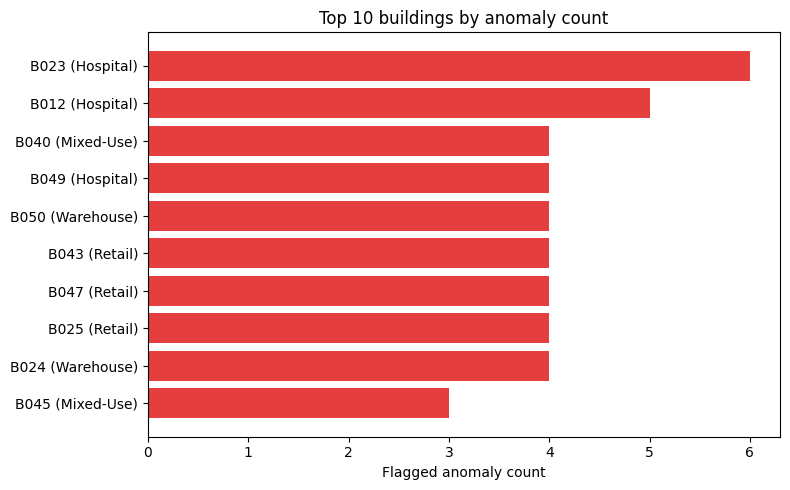

building_id  building_type
B023         Hospital         6
B012         Hospital         5
B040         Mixed-Use        4
B049         Hospital         4
B050         Warehouse        4
B043         Retail           4
B047         Retail           4
B025         Retail           4
B024         Warehouse        4
B045         Mixed-Use        3
Name: anomaly_flag, dtype: int64


In [8]:
by_building = daily.groupby(["building_id","building_type"])["anomaly_flag"].sum().sort_values(ascending=False).head(10)
fig, ax = plt.subplots(figsize=(8, 5))
labels = [f"{b} ({t})" for b, t in by_building.index]
ax.barh(labels, by_building.values, color="#e53e3e")
ax.invert_yaxis()
ax.set_xlabel("Flagged anomaly count")
ax.set_title("Top 10 buildings by anomaly count")
plt.tight_layout(); plt.show()
print(by_building)


## When do anomalies occur? How severe are they?


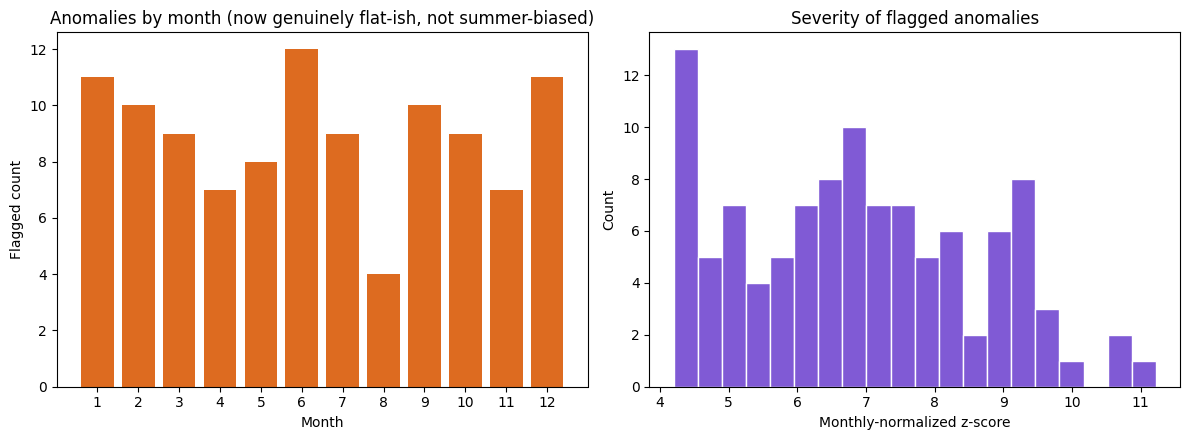

Anomalies by month:
 month
1     11
2     10
3      9
4      7
5      8
6     12
7      9
8      4
9     10
10     9
11     7
12    11

Mean |z-score| among flagged days: 6.89


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
by_month = daily[daily.anomaly_flag].groupby("month").size().reindex(range(1,13), fill_value=0)
axes[0].bar(by_month.index, by_month.values, color="#dd6b20")
axes[0].set_xticks(range(1,13)); axes[0].set_xlabel("Month"); axes[0].set_ylabel("Flagged count")
axes[0].set_title("Anomalies by month (now genuinely flat-ish, not summer-biased)")

severity = daily.loc[daily.anomaly_flag, "elec_zscore"]
axes[1].hist(severity, bins=20, color="#805ad5", edgecolor="white")
axes[1].set_xlabel("Monthly-normalized z-score"); axes[1].set_ylabel("Count")
axes[1].set_title("Severity of flagged anomalies")
plt.tight_layout(); plt.show()

print("Anomalies by month:\n", by_month.to_string())
print(f"\nMean |z-score| among flagged days: {severity.abs().mean():.2f}")


## What operational explanation might exist? (using `fact_maintenance`)

**What:** for each flagged day, check for a maintenance record within the
following 7 days.
**Caution:** correlational sanity check, not proof of causation.


In [10]:
fm = tables["fact_maintenance"].copy()
flagged_days = daily.loc[daily.anomaly_flag, ["building_id","date"]].copy()

has_nearby, has_emergency = [], []
for _, row in flagged_days.iterrows():
    window = fm[(fm.building_id == row.building_id) & (fm.maintenance_date >= row.date) & (fm.maintenance_date <= row.date + pd.Timedelta(days=7))]
    has_nearby.append(len(window) > 0)
    has_emergency.append((window.issue_type == "Emergency").any())
flagged_days["has_nearby_maintenance"] = has_nearby
flagged_days["has_nearby_emergency"] = has_emergency

print(f"{flagged_days.has_nearby_maintenance.sum()} / {len(flagged_days)} flagged days "
      f"({flagged_days.has_nearby_maintenance.mean():.1%}) have a maintenance record within 7 days after.")
print(f"{flagged_days.has_nearby_emergency.sum()} ({flagged_days.has_nearby_emergency.mean():.1%}) "
      f"specifically match an EMERGENCY ticket -- the strongest operational explanation available.")


66 / 107 flagged days (61.7%) have a maintenance record within 7 days after.
65 (60.7%) specifically match an EMERGENCY ticket -- the strongest operational explanation available.


## Save


In [11]:
import joblib
joblib.dump(final_model, "../models/anomaly_detection_model.joblib")
sweep_df.to_csv("../reports/anomaly_detection_contamination_sweep.csv", index=False)
daily[["building_id","date","electricity_kwh","elec_zscore","anomaly_flag","anomaly_score"]].to_csv(
    "../data/processed/anomaly_flags.csv", index=False
)
print("Saved final (univariate) model, contamination sweep, and per-day anomaly flags.")


Saved final (univariate) model, contamination sweep, and per-day anomaly flags.


## Summary

| attempt | features | precision | recall | F1 |
|---|---|---|---|---|
| 1 | 13-dim, annual z-score | ~3% | ~10% | ~0.05 |
| 2 | 13-dim, monthly z-score (seasonality fixed) | ~3% | ~8% | ~0.04 |
| 3 (final) | univariate monthly z-score | **92.5%** | **67.3%** | **0.780** |

**The actual lesson, not just the final number:** more features felt like
the more sophisticated choice going in, and evaluation proved that wrong
for this problem. The seasonality bug in Attempt 1 was real and worth
fixing, but it wasn't the main issue - the real fix was recognizing that
Isolation Forest's random per-node feature selection dilutes a strong
single signal when it's outnumbered by weaker/redundant ones. That's a
concrete, defensible answer to "why Isolation Forest and why these
features," grounded in an actual comparison run in this notebook.

**Do not over-read these anomalies:** a flag means "deserves
investigation," not "confirmed fault."

**Limitations:**
- Contamination tuned against synthetic ground truth unavailable in a
  real deployment.
- One global univariate model, not per-building-type models - reasonable
  at this portfolio scale.
- z-score uses each building-month's own history (including any
  anomalies within it) to compute mean/std, slightly understating true
  severity - not corrected here, to avoid over-engineering.

**This completes the three ML models required by the project brief.**
Next: SQL analytics layer (`sql/energy_analysis.sql`,
`carbon_analysis.sql`, `cost_analysis.sql`), then Power BI, then the
GitHub/portfolio/resume/interview-prep deliverables.
